In [1]:
# Import core libraries.
# pandas: loads and manipulates tabular data (like a spreadsheet, but in code)
# numpy: numerical operations, used internally by pandas and scikit-learn
import pandas as pd
import numpy as np

# Load the dataset from the data/ folder.
# "../" steps up one directory: this notebook lives in notebooks/,
# and the dataset lives in data/, so this path reaches it correctly.
df = pd.read_csv("../data/credit_card_fraud_2026.csv")

# Print the shape: (number of rows, number of columns).
# This is the first sanity check on any dataset - confirms it loaded
# and matches expectations (~20,000 rows expected here).
print(df.shape)

(20000, 26)


In [2]:
# List all column names in the dataset.
# We've only seen a partial preview on Kaggle - this confirms every
# column actually present, including ones not shown earlier
# (e.g. velocity_score, distance_from_home_km, is_ai_generated_scam_attempt).
print(df.columns.tolist())

['transaction_id', 'amount_usd', 'merchant_category', 'card_type', 'auth_method', 'channel', 'device_type', 'is_foreign_transaction', 'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km', 'card_age_months', 'customer_age', 'account_balance_usd', 'is_new_merchant', 'used_vpn', 'ip_country_mismatch', 'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score', 'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt', 'merchant_risk_score', 'prior_disputes', 'is_fraud']


In [3]:
# Check the class balance of the target column, is_fraud.
# value_counts() shows how many rows fall into each category (0 = not fraud, 1 = fraud).
# normalize=True converts those counts into percentages instead of raw numbers,
# making the imbalance immediately obvious.
print(df["is_fraud"].value_counts())
print(df["is_fraud"].value_counts(normalize=True))

is_fraud
0    19661
1      339
Name: count, dtype: int64
is_fraud
0    0.98305
1    0.01695
Name: proportion, dtype: float64


In [4]:
# Check for missing values in every column.
# isnull() marks each cell True/False (missing or not), and sum() adds
# those up per column - giving a count of missing values for each feature.
# A clean, well-behaved dataset (like this one likely is, since it's
# synthetic) should show all zeros, but we check explicitly rather than
# assuming.
print(df.isnull().sum())

transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64


In [5]:
# Check the data type of every column.
# This tells us which columns are numbers (int64/float64), which are
# text/categories (object), and which are true/false flags (bool).
# We need this to know which columns need encoding later (categories
# like auth_method) versus which are already usable as-is (numbers).
print(df.dtypes)

transaction_id                    int64
amount_usd                      float64
merchant_category                   str
card_type                           str
auth_method                         str
channel                             str
device_type                         str
is_foreign_transaction             bool
hours_since_last_txn            float64
txn_count_last_24h                int64
distance_from_home_km           float64
card_age_months                   int64
customer_age                      int64
account_balance_usd             float64
is_new_merchant                    bool
used_vpn                           bool
ip_country_mismatch                bool
billing_shipping_mismatch          bool
cvv_retry_count                   int64
velocity_score                  float64
time_of_day_hour                  int64
day_of_week                       int64
is_ai_generated_scam_attempt       bool
merchant_risk_score             float64
prior_disputes                    int64


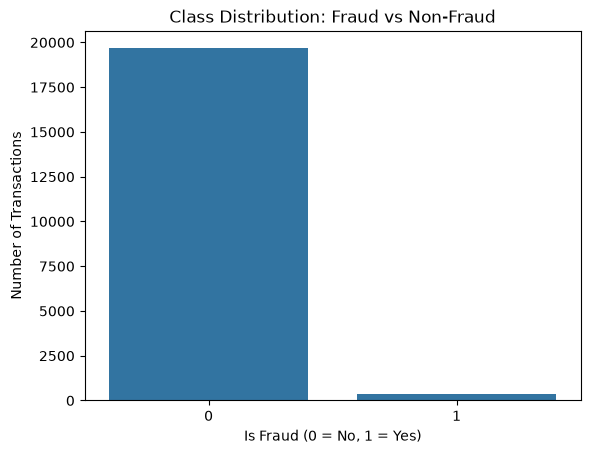

In [6]:
# Visualize the class imbalance as a bar chart.
# matplotlib.pyplot is the standard plotting library; we import it as plt
# by convention. seaborn (sns) builds on top of matplotlib with nicer
# default styling, useful for a portfolio-quality chart.
import matplotlib.pyplot as plt
import seaborn as sns

# Count how many transactions fall into each class (0 = not fraud, 1 = fraud).
sns.countplot(data=df, x="is_fraud")
plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions")
plt.show()

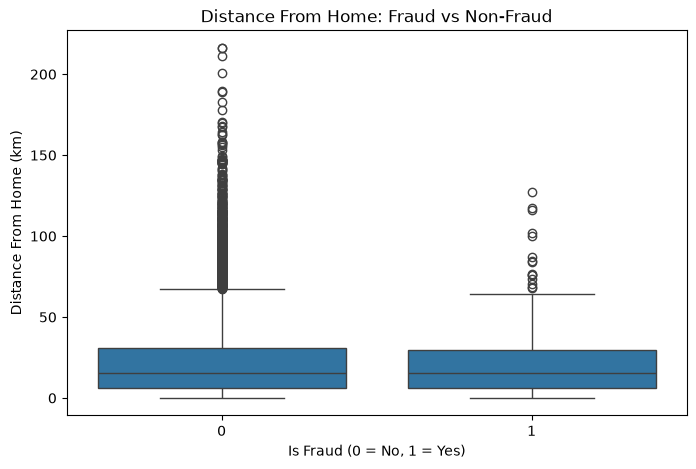

In [7]:
# Compare a key feature - distance_from_home_km - between fraud and
# non-fraud transactions. A boxplot shows the spread (median, quartiles,
# outliers) for each group side by side, making differences visually obvious.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_fraud", y="distance_from_home_km")
plt.title("Distance From Home: Fraud vs Non-Fraud")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Distance From Home (km)")
plt.show()

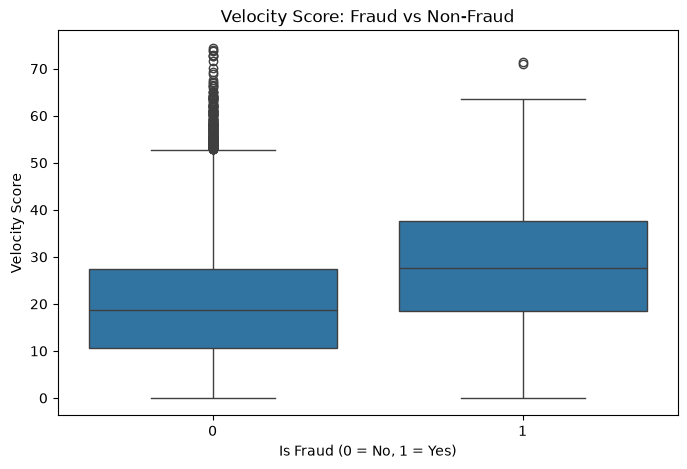

In [8]:
# Compare velocity_score between fraud and non-fraud transactions.
# velocity_score often captures rapid, suspicious transaction patterns,
# so it may show a clearer separation than distance_from_home_km did.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_fraud", y="velocity_score")
plt.title("Velocity Score: Fraud vs Non-Fraud")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Velocity Score")
plt.show()

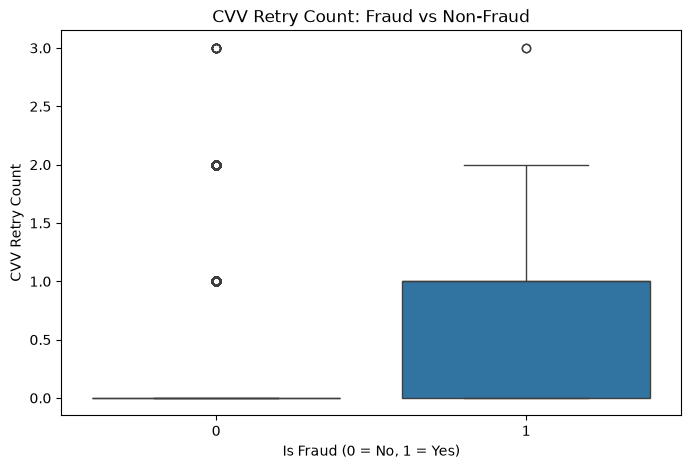

In [9]:
# Compare cvv_retry_count between fraud and non-fraud transactions.
# Repeated CVV entry attempts often indicate someone guessing card details,
# a common fraud pattern, so this may show a strong separation.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_fraud", y="cvv_retry_count")
plt.title("CVV Retry Count: Fraud vs Non-Fraud")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("CVV Retry Count")
plt.show()

In [10]:
# Check how strongly each numeric column relates to is_fraud.
# corr() calculates correlation coefficients between all numeric columns.
# We only care about each column's relationship to is_fraud specifically,
# so we select that one column from the result and sort it, largest
# magnitude first, to immediately see the strongest signals.
#
# numeric_only=True excludes text columns (like auth_method), which
# correlation math cannot be applied to directly.
correlations = df.corr(numeric_only=True)["is_fraud"].sort_values(ascending=False)
print(correlations)

is_fraud                        1.000000
cvv_retry_count                 0.155509
ip_country_mismatch             0.117763
merchant_risk_score             0.107680
billing_shipping_mismatch       0.100863
velocity_score                  0.097255
is_foreign_transaction          0.083494
is_ai_generated_scam_attempt    0.078941
is_new_merchant                 0.076401
used_vpn                        0.064532
txn_count_last_24h              0.059866
amount_usd                      0.024951
prior_disputes                  0.023903
customer_age                    0.019543
day_of_week                     0.006071
account_balance_usd             0.004371
distance_from_home_km          -0.004292
transaction_id                 -0.005357
card_age_months                -0.012065
hours_since_last_txn           -0.028798
time_of_day_hour               -0.030814
Name: is_fraud, dtype: float64


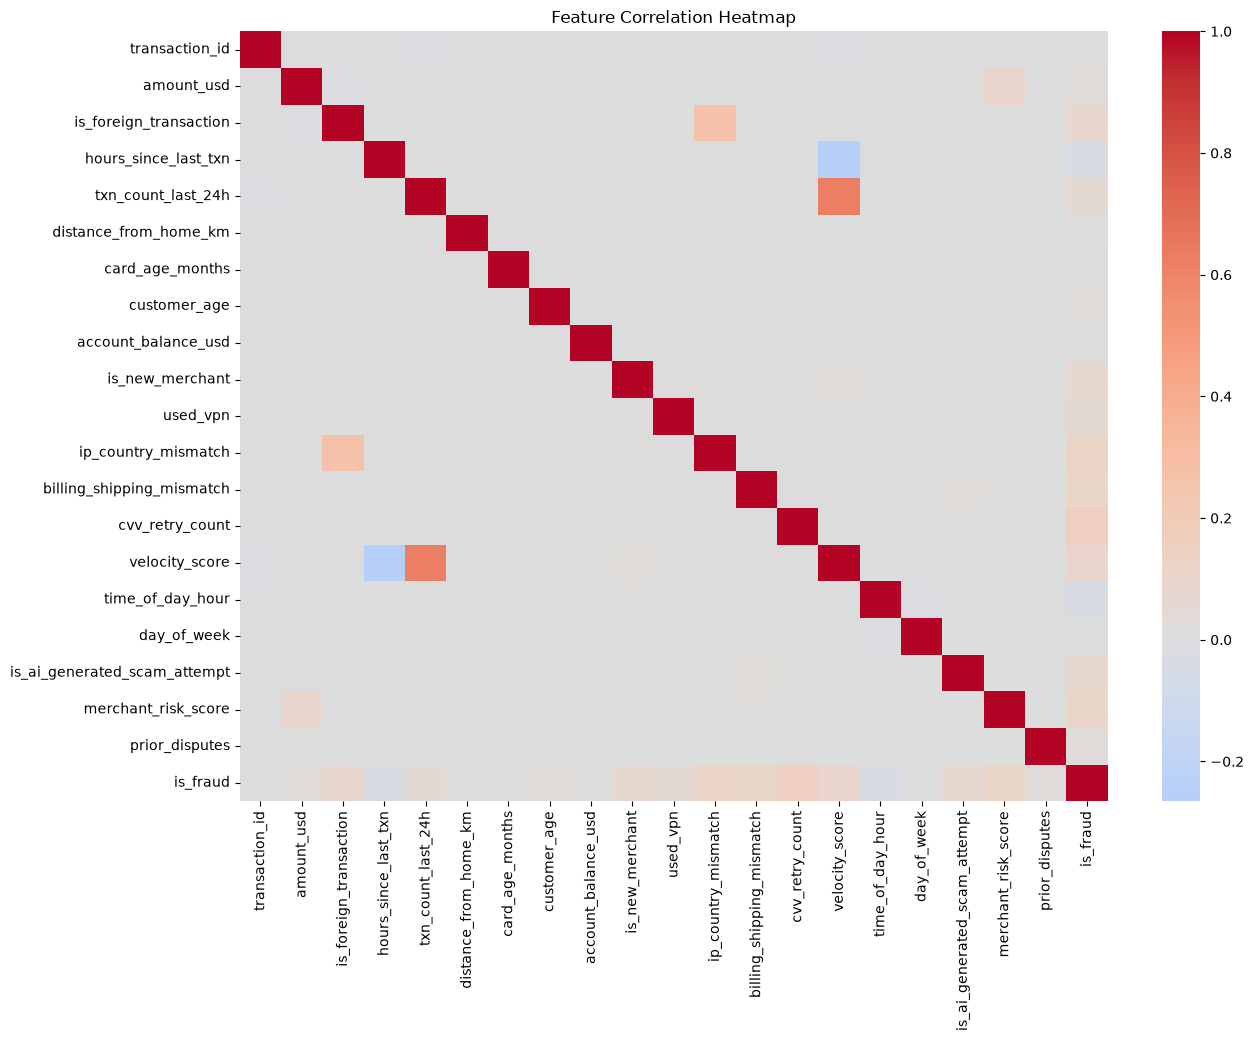

In [11]:
# Visualize correlations between all numeric features as a heatmap.
# This gives a full picture at once, not just each feature's relationship
# to is_fraud, but how features relate to each other too (useful context,
# e.g. if two features are highly correlated with each other, that's
# worth knowing before modeling).
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()